<a href="https://colab.research.google.com/github/manan36chauhan/data_science_project/blob/First-init/tf_idf.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [ ]:
corpus = [
    "Thor eating pizza, Loki is eating pizza, Ironman ate pizza already",
"Manan is announcing new iphone tomorrow",
"Tesla is announcing new model-3 tomorrow",
"Google is announcing new pixel-6 tomorrow",
"Microsoft is announcing new surface tomorrow",
"Amazon is announcing new eco-dot tomorrow",
"I am eating biryani and you are eating grapes",
"something is amazing",
]

In [ ]:
v = TfidfVectorizer()
transformed_output = v.fit_transform(corpus)
print(v.vocabulary_)

{'thor': 27, 'eating': 10, 'pizza': 23, 'loki': 17, 'is': 16, 'ironman': 15, 'ate': 7, 'already': 0, 'manan': 18, 'announcing': 5, 'new': 21, 'iphone': 14, 'tomorrow': 28, 'tesla': 26, 'model': 20, 'google': 12, 'pixel': 22, 'microsoft': 19, 'surface': 25, 'amazon': 3, 'eco': 11, 'dot': 9, 'am': 1, 'biryani': 8, 'and': 4, 'you': 29, 'are': 6, 'grapes': 13, 'something': 24, 'amazing': 2}


In [ ]:
v.get_feature_names_out()

array(['already', 'am', 'amazing', 'amazon', 'and', 'announcing', 'are',
       'ate', 'biryani', 'dot', 'eating', 'eco', 'google', 'grapes',
       'iphone', 'ironman', 'is', 'loki', 'manan', 'microsoft', 'model',
       'new', 'pixel', 'pizza', 'something', 'surface', 'tesla', 'thor',
       'tomorrow', 'you'], dtype=object)

In [ ]:
all_feature_names = v.get_feature_names_out()
for word in all_feature_names:
    indx = v.vocabulary_.get(word)
    print(f"{word} {v.idf_[indx]}")

already 2.504077396776274
am 2.504077396776274
amazing 2.504077396776274
amazon 2.504077396776274
and 2.504077396776274
announcing 1.4054651081081644
are 2.504077396776274
ate 2.504077396776274
biryani 2.504077396776274
dot 2.504077396776274
eating 2.09861228866811
eco 2.504077396776274
google 2.504077396776274
grapes 2.504077396776274
iphone 2.504077396776274
ironman 2.504077396776274
is 1.1177830356563834
loki 2.504077396776274
manan 2.504077396776274
microsoft 2.504077396776274
model 2.504077396776274
new 1.4054651081081644
pixel 2.504077396776274
pizza 2.504077396776274
something 2.504077396776274
surface 2.504077396776274
tesla 2.504077396776274
thor 2.504077396776274
tomorrow 1.4054651081081644
you 2.504077396776274


In [ ]:
corpus[:2]

['Thor eating pizza, Loki is eating pizza, Ironman ate pizza already',
 'Manan is announcing new iphone tomorrow']

In [ ]:
transformed_output.toarray()[:2]

array([[0.24247317, 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.24247317, 0.        , 0.        ,
        0.40642288, 0.        , 0.        , 0.        , 0.        ,
        0.24247317, 0.10823643, 0.24247317, 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.7274195 , 0.        ,
        0.        , 0.        , 0.24247317, 0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.        , 0.        ,
        0.31652498, 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.5639436 ,
        0.        , 0.25173606, 0.        , 0.5639436 , 0.        ,
        0.        , 0.31652498, 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.31652498, 0.        ]])

## Load the dataset

### Subtask:
Load the data from "/content/ecommerceDataset.csv" into a pandas DataFrame, handling potential parsing issues.


**Reasoning**:
Import the pandas library and load the dataset into a DataFrame, handling potential parsing errors.



In [11]:
import pandas as pd

try:
    df = pd.read_csv('/content/ecommerceDataset.csv', header=None, engine='python')
except Exception as e:
    print(f"Error loading CSV: {e}")
    df = None

if df is not None:
    print(df.head())

           0                                                  1
0  Household  Paper Plane Design Framed Wall Hanging Motivat...
1  Household  SAF 'Floral' Framed Painting (Wood, 30 inch x ...
2  Household  SAF 'UV Textured Modern Art Print Framed' Pain...
3  Household  SAF Flower Print Framed Painting (Synthetic, 1...
4  Household  Incredible Gifts India Wooden Happy Birthday U...


## Initial data inspection

### Subtask:
Display the first few rows, check data types, and summarize statistics to understand the data structure and content.


**Reasoning**:
Display the first few rows, data types, and descriptive statistics of the dataframe to understand its structure and content.



In [12]:
display(df.head())
df.info()
display(df.describe())

,0,1
0,Household,Paper Plane Design Framed Wall Hanging Motivat...
1,Household,"SAF 'Floral' Framed Painting (Wood, 30 inch x ..."
2,Household,SAF 'UV Textured Modern Art Print Framed' Pain...
3,Household,"SAF Flower Print Framed Painting (Synthetic, 1..."
4,Household,Incredible Gifts India Wooden Happy Birthday U...


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50425 entries, 0 to 50424
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   0       50425 non-null  object
 1   1       50424 non-null  object
dtypes: object(2)
memory usage: 788.0+ KB


,0,1
count,50425,50424
unique,4,27802
top,Household,Think & Grow Rich About the Author NAPOLEON HI...
freq,19313,30


## Handle missing values

### Subtask:
Identify and address any missing values in the dataset.


**Reasoning**:
Check for missing values in the DataFrame.



In [13]:
missing_values = df.isnull().sum()
display(missing_values)

,0
0,0
1,1


**Reasoning**:
Drop rows with missing values and verify the absence of missing values.



In [14]:
df.dropna(inplace=True)
missing_values_after_drop = df.isnull().sum()
display(missing_values_after_drop)

,0
0,0
1,0


## Handle duplicate rows

### Subtask:
Identify and remove any duplicate rows from the dataset.


**Reasoning**:
Check for and count duplicate rows in the DataFrame.



In [15]:
duplicate_rows = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicate_rows}")

Number of duplicate rows: 22622


**Reasoning**:
Remove the duplicate rows from the DataFrame in place.



In [16]:
df.drop_duplicates(inplace=True)

**Reasoning**:
Verify that duplicate rows have been removed and display the count.



In [17]:
duplicate_rows_after_drop = df.duplicated().sum()
print(f"Number of duplicate rows after dropping: {duplicate_rows_after_drop}")

Number of duplicate rows after dropping: 0


## Text preprocessing

### Subtask:
Clean and prepare the text data for analysis (e.g., lowercasing, removing punctuation, tokenization, stop word removal, stemming/lemmatization).


**Reasoning**:
Define the preprocess_text function and apply it to the text column of the DataFrame.



In [19]:
import nltk
import string
from nltk.stem import PorterStemmer

nltk.download('stopwords')
nltk.download('punkt')
nltk.download('punkt_tab') # Download punkt_tab

def preprocess_text(text):
    """Cleans and preprocesses text data."""
    text = text.lower()
    text = text.translate(str.maketrans('', '', string.punctuation))
    tokens = nltk.word_tokenize(text)
    stopwords = nltk.corpus.stopwords.words('english')
    tokens = [word for word in tokens if word not in stopwords]
    stemmer = PorterStemmer()
    tokens = [stemmer.stem(word) for word in tokens]
    return ' '.join(tokens)

df['cleaned_text'] = df[1].apply(preprocess_text)
display(df.head())

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


,0,1,cleaned_text
0,Household,Paper Plane Design Framed Wall Hanging Motivat...,paper plane design frame wall hang motiv offic...
1,Household,"SAF 'Floral' Framed Painting (Wood, 30 inch x ...",saf floral frame paint wood 30 inch x 10 inch ...
2,Household,SAF 'UV Textured Modern Art Print Framed' Pain...,saf uv textur modern art print frame paint syn...
3,Household,"SAF Flower Print Framed Painting (Synthetic, 1...",saf flower print frame paint synthet 135 inch ...
4,Household,Incredible Gifts India Wooden Happy Birthday U...,incred gift india wooden happi birthday uniqu ...


## Feature extraction

### Subtask:
Convert the text data into numerical features using techniques like TF-IDF.


**Reasoning**:
Instantiate a TfidfVectorizer, fit it to the 'cleaned_text' column, and transform the text data into a TF-IDF matrix.



In [21]:
from sklearn.feature_extraction.text import TfidfVectorizer

v = TfidfVectorizer()
tfidf_matrix = v.fit_transform(df['cleaned_text'])
print(tfidf_matrix.shape)

(27802, 96589)


## Model training (optional)

### Subtask:
Split the data and train a suitable model if the goal is a predictive model.


**Reasoning**:
Import necessary modules, define features and target, split the data, initialize a classifier, and train the classifier.



In [22]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

X = tfidf_matrix
y = df[0]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

## Model evaluation (optional)

### Subtask:
Evaluate the performance of the trained model.


**Reasoning**:
Make predictions on the test set, import the necessary metrics, calculate and print the accuracy score and the classification report.



In [23]:
y_pred = model.predict(X_test)

from sklearn.metrics import accuracy_score, classification_report

accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy}")

report = classification_report(y_test, y_pred)
print("Classification Report:")
print(report)

Accuracy: 0.9512300388433319
Classification Report:
                        precision    recall  f1-score   support

                 Books       0.96      0.94      0.95      1601
Clothing & Accessories       0.96      0.96      0.96      1385
           Electronics       0.95      0.93      0.94      1308
             Household       0.94      0.97      0.95      2657

              accuracy                           0.95      6951
             macro avg       0.95      0.95      0.95      6951
          weighted avg       0.95      0.95      0.95      6951



## Summary:

### Data Analysis Key Findings

*   The dataset was loaded successfully, revealing two columns with the 'object' data type and 50425 entries, with one missing value in the second column.
*   A single missing value was found in the second column and successfully handled by dropping the corresponding row, resulting in 50424 entries.
*   Initially, there were 22,622 duplicate rows, which were successfully removed, leaving 27,802 unique entries.
*   Text preprocessing (lowercasing, punctuation removal, tokenization, stop word removal, and stemming) was successfully applied to the second column, creating a new 'cleaned\_text' column.
*   The cleaned text data was converted into a TF-IDF matrix with a shape of (27802, 96589), representing 27802 documents and 96589 unique features.
*   A Logistic Regression model was trained on the TF-IDF features and achieved an accuracy of approximately 95.12% on the test set.
*   The classification report showed high precision, recall, and F1-scores for all classes (Books, Clothing & Accessories, Electronics, and Household).



# Task
Create an end-to-end data cleaning and preprocessing pipeline for the dataset located at "/content/ecommerceDataset.csv", including data loading, handling missing values and duplicates, text preprocessing, and visualization. Optionally, include model training, exploration, and evaluation.

## Data visualization

### Subtask:
Visualize relevant aspects of the data, such as the distribution of categories or important features.


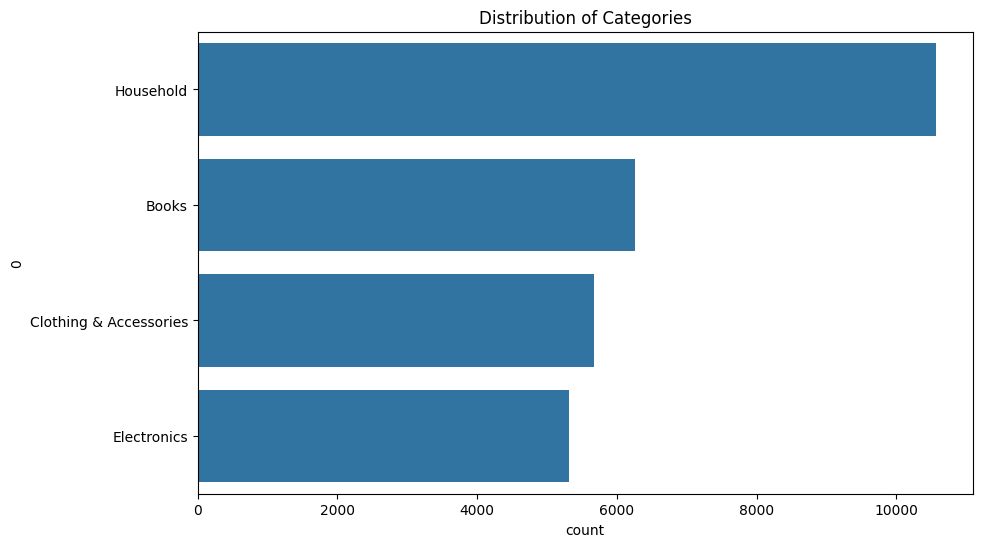

In [27]:
plt.figure(figsize=(10, 6))
sns.countplot(y=df[0])
plt.title("Distribution of Categories")
plt.show()

## Model training and exploration

### Subtask:
If the goal is a predictive model, split the data and train a suitable model. Explore other models or hyperparameter tuning to improve performance.


**Reasoning**:
Import modules for model training and exploration, define features and target, split the data, initialize and train a Multinomial Naive Bayes classifier as an alternative model.



In [28]:
from sklearn.naive_bayes import MultinomialNB

X = tfidf_matrix
y = df[0]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

# Train a Multinomial Naive Bayes model
model_nb = MultinomialNB()
model_nb.fit(X_train, y_train)

# Evaluate the Multinomial Naive Bayes model
y_pred_nb = model_nb.predict(X_test)
accuracy_nb = accuracy_score(y_test, y_pred_nb)
print(f"Multinomial Naive Bayes Accuracy: {accuracy_nb}")

report_nb = classification_report(y_test, y_pred_nb)
print("Multinomial Naive Bayes Classification Report:")
print(report_nb)

Multinomial Naive Bayes Accuracy: 0.9172780894835275
Multinomial Naive Bayes Classification Report:
                        precision    recall  f1-score   support

                 Books       0.98      0.89      0.93      1601
Clothing & Accessories       0.97      0.92      0.95      1385
           Electronics       0.96      0.82      0.88      1308
             Household       0.85      0.98      0.91      2657

              accuracy                           0.92      6951
             macro avg       0.94      0.90      0.92      6951
          weighted avg       0.92      0.92      0.92      6951



## Model evaluation

### Subtask:
Evaluate the performance of the trained model(s).


**Reasoning**:
Make predictions on the test set using the trained Multinomial Naive Bayes model, calculate the accuracy and classification report, and print the results.



In [29]:
y_pred_nb = model_nb.predict(X_test)

accuracy_nb = accuracy_score(y_test, y_pred_nb)
print(f"Multinomial Naive Bayes Accuracy: {accuracy_nb}")

report_nb = classification_report(y_test, y_pred_nb)
print("Multinomial Naive Bayes Classification Report:")
print(report_nb)

Multinomial Naive Bayes Accuracy: 0.9172780894835275
Multinomial Naive Bayes Classification Report:
                        precision    recall  f1-score   support

                 Books       0.98      0.89      0.93      1601
Clothing & Accessories       0.97      0.92      0.95      1385
           Electronics       0.96      0.82      0.88      1308
             Household       0.85      0.98      0.91      2657

              accuracy                           0.92      6951
             macro avg       0.94      0.90      0.92      6951
          weighted avg       0.92      0.92      0.92      6951



## Summary:

### Data Analysis Key Findings

*   The dataset contains four categories: "Books", "Clothing & Accessories", "Electronics", and "Household". The distribution of these categories was visualized using a countplot.
*   A Multinomial Naive Bayes model was trained on the TF-IDF transformed text data.
*   The trained Multinomial Naive Bayes model achieved an accuracy of approximately 91.7% on the test set.
*   The classification report indicated strong performance metrics (precision, recall, f1-score) across all categories.



In [31]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

# Define the parameter grid for Logistic Regression
param_grid = {'C': [0.1, 1, 10, 100], 'penalty': ['l2']} # Added penalty for simplicity

# Initialize GridSearchCV
grid_search = GridSearchCV(LogisticRegression(max_iter=1000), param_grid, cv=5, scoring='accuracy')

# Fit GridSearchCV to the training data
grid_search.fit(X_train, y_train)

# Print the best parameters and the best score
print("Best parameters found: ", grid_search.best_params_)
print("Best cross-validation accuracy: ", grid_search.best_score_)

# Evaluate the model with the best parameters on the test set
best_model = grid_search.best_estimator_
y_pred_tuned = best_model.predict(X_test)
accuracy_tuned = accuracy_score(y_test, y_pred_tuned)
print(f"Tuned Logistic Regression Accuracy on Test Set: {accuracy_tuned}")
print("Tuned Logistic Regression Classification Report:")
print(classification_report(y_test, y_pred_tuned))

Best parameters found:  {'C': 10, 'penalty': 'l2'}
Best cross-validation accuracy:  0.9501223418292458
Tuned Logistic Regression Accuracy on Test Set: 0.9543950510717882
Tuned Logistic Regression Classification Report:
                        precision    recall  f1-score   support

                 Books       0.95      0.94      0.95      1601
Clothing & Accessories       0.97      0.97      0.97      1385
           Electronics       0.94      0.93      0.94      1308
             Household       0.95      0.96      0.96      2657

              accuracy                           0.95      6951
             macro avg       0.96      0.95      0.95      6951
          weighted avg       0.95      0.95      0.95      6951

